# Sistema con ciclo límite elíptico

*(Traducción a Python de `eliptica.m`, usando `numpy`, `scipy` y `matplotlib`)*

$$\dot x_1 = \mu_1 x_2, \qquad \dot x_2 = -\mu_2 x_1 - x_2(x_1^2+4x_2^2-4)$$

**Nota sobre la estructura del `.m` original:** en MATLAB, `eliptica.m` es un archivo con una función principal `eliptica()` (sin argumentos, que hace todo el trabajo) y una función local `elip(t,x,mu)` con las ecuaciones de estado, ambas en el mismo archivo. En Python replicamos la misma idea: una función `elip` con las ecuaciones, y el resto del código (el bucle y el dibujo) directamente en las celdas del notebook, sin necesidad de envolverlo en una función aparte.

In [1]:
import numpy as np
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt

np.set_printoptions(precision=4, suppress=True)

## Función de estado (equivalente a `elip`)

In [2]:
def elip(t, x, mu):
    """Ecuaciones de estado del sistema con ciclo limite eliptico."""
    x1, x2 = x
    xdot1 = mu[0]*x2
    xdot2 = -mu[1]*x1 - x2*(x1**2 + 4*x2**2 - 4)
    return [xdot1, xdot2]

## Retrato de fases

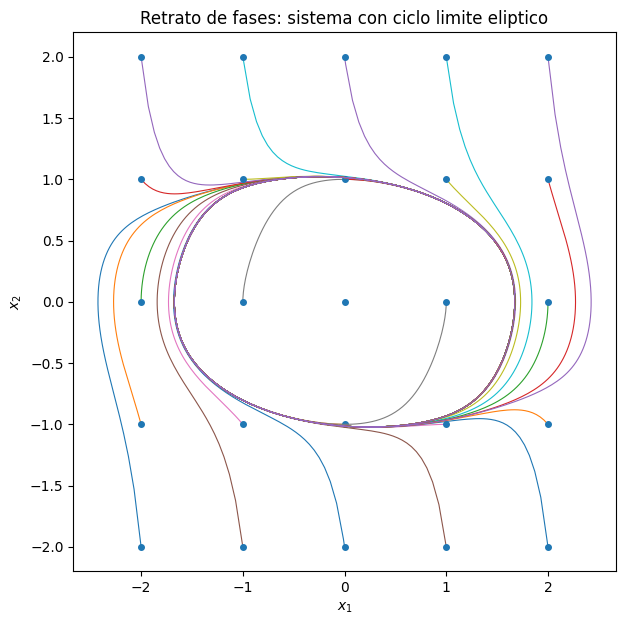

In [3]:
x10 = np.arange(-2, 2.001, 1)
x20 = x10.copy()
mu = [2, 1]

fig, ax = plt.subplots(figsize=(7, 7))

for i in x10:
    for j in x20:
        sol = solve_ivp(elip, [0, 10], [i, j], args=(mu,), max_step=0.02)
        ax.plot(sol.y[0], sol.y[1], linewidth=0.8)
        ax.plot(i, j, 'o', color='tab:blue', markersize=4)

ax.set_xlabel('$x_1$')
ax.set_ylabel('$x_2$')
ax.set_title('Retrato de fases: sistema con ciclo limite eliptico')
plt.show()

Todas las trayectorias, independientemente de la condición inicial, terminan convergiendo hacia el mismo ciclo límite (una órbita periódica cerrada de forma elíptica) — es la firma característica de un ciclo límite estable.